# 🏆 Project 79 of 100 – Nobel Prize Data Analysis 🇨🇴
---

## 🔎 📊 🏆 Introduction

Alfred Nobel dedicated his fortune to rewarding those who bring
the greatest benefit to humankind.

In this project, I analyze over a century of Nobel Prize data
to uncover patterns across geography, gender, time, and disciplines.

This notebook combines data cleaning, exploratory analysis,
interactive visualization, and statistical modeling.

Let’s explore history through data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## 📂 Loading the Dataset

In [3]:
df_data = pd.read_csv('nobel_prize_data.csv')

Caveats: The exact birth dates for Michael Houghton, Venkatraman Ramakrishnan, and Nadia Murad are unknown. I've substituted them with mid-year estimate of July 2nd. 

## 🔎 Dataset Overview

### Preliminary data exploration.

* What is the shape of `df_data`? How many rows and columns?
* What are the column names?
* In which year was the Nobel prize first awarded?
* Which year is the latest year included in the dataset?

In [4]:
df_data.shape

(962, 16)

In [5]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   year                   962 non-null    int64
 1   category               962 non-null    str  
 2   prize                  962 non-null    str  
 3   motivation             874 non-null    str  
 4   prize_share            962 non-null    str  
 5   laureate_type          962 non-null    str  
 6   full_name              962 non-null    str  
 7   birth_date             934 non-null    str  
 8   birth_city             931 non-null    str  
 9   birth_country          934 non-null    str  
 10  birth_country_current  934 non-null    str  
 11  sex                    934 non-null    str  
 12  organization_name      707 non-null    str  
 13  organization_city      707 non-null    str  
 14  organization_country   708 non-null    str  
 15  ISO                    934 non-null    str  
dtypes

## 🧹 Data Cleaning

- Convert `birth_date` column to datetime
- Inspect missing values
- Ensure consistent formatting
- Add a Column with the Prize Share as a Percentage 

In [6]:
df_data['birth_date']= pd.to_datetime(df_data.birth_date)

### 🔎 Check for Duplicates and NaN Values

In [7]:
print(f'Any duplicates? {df_data.duplicated().values.any()}')
print(f'Any NaN values among the data? {df_data.isna().values.any()}')

Any duplicates? False
Any NaN values among the data? True


In [8]:
df_data.isna().sum()

year                       0
category                   0
prize                      0
motivation                88
prize_share                0
laureate_type              0
full_name                  0
birth_date                28
birth_city                31
birth_country             28
birth_country_current     28
sex                       28
organization_name        255
organization_city        255
organization_country     254
ISO                       28
dtype: int64

Why are there NaN values for birth dates? 

In [9]:
# NaN values for birth date are all organisations
col_subset = ['year','category', 'laureate_type',
              'birth_date','full_name', 'organization_name']
df_data.loc[df_data['birth_date'].isna()][col_subset]

,year,category,laureate_type,birth_date,full_name,organization_name
24,1904,Peace,Organization,NaT,Institut de droit international (Institute of ...,NaN
60,1910,Peace,Organization,NaT,Bureau international permanent de la Paix (Per...,NaN
89,1917,Peace,Organization,NaT,Comité international de la Croix Rouge (Intern...,NaN
200,1938,Peace,Organization,NaT,Office international Nansen pour les Réfugiés ...,NaN
215,1944,Peace,Organization,NaT,Comité international de la Croix Rouge (Intern...,NaN
237,1947,Peace,Organization,NaT,American Friends Service Committee (The Quakers),NaN
238,1947,Peace,Organization,NaT,Friends Service Council (The Quakers),NaN
283,1954,Peace,Organization,NaT,Office of the United Nations High Commissioner...,NaN
348,1963,Peace,Organization,NaT,Comité international de la Croix Rouge (Intern...,NaN
349,1963,Peace,Organization,NaT,Ligue des Sociétés de la Croix-Rouge (League o...,NaN


In [10]:
# NaN values for organisation_name
col_subset = ['year','category', 'laureate_type','full_name', 'organization_name']
df_data.loc[df_data['organization_name'].isna()][col_subset]

,year,category,laureate_type,full_name,organization_name
1,1901,Literature,Individual,Sully Prudhomme,NaN
3,1901,Peace,Individual,Frédéric Passy,NaN
4,1901,Peace,Individual,Jean Henry Dunant,NaN
7,1902,Literature,Individual,Christian Matthias Theodor Mommsen,NaN
9,1902,Peace,Individual,Charles Albert Gobat,NaN
...,...,...,...,...,...
932,2018,Peace,Individual,Nadia Murad,NaN
942,2019,Literature,Individual,Peter Handke,NaN
946,2019,Peace,Individual,Abiy Ahmed Ali,NaN
954,2020,Literature,Individual,Louise Glück,NaN


Some prizes are given to Organisations rather than individuals!

In [11]:
separated_values = df_data.prize_share.str.split('/', expand=True)
numerator = pd.to_numeric(separated_values[0])
denomenator = pd.to_numeric(separated_values[1])
df_data['share_pct'] = numerator / denomenator

In [12]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    str           
 2   prize                  962 non-null    str           
 3   motivation             874 non-null    str           
 4   prize_share            962 non-null    str           
 5   laureate_type          962 non-null    str           
 6   full_name              962 non-null    str           
 7   birth_date             934 non-null    datetime64[us]
 8   birth_city             931 non-null    str           
 9   birth_country          934 non-null    str           
 10  birth_country_current  934 non-null    str           
 11  sex                    934 non-null    str           
 12  organization_name      707 non-null    str           
 13  organization_cit

## 🍩 Plotly Donut Chart: 🧑‍🔬 Percentage of Male vs. 👩‍🔬 Female Laureates

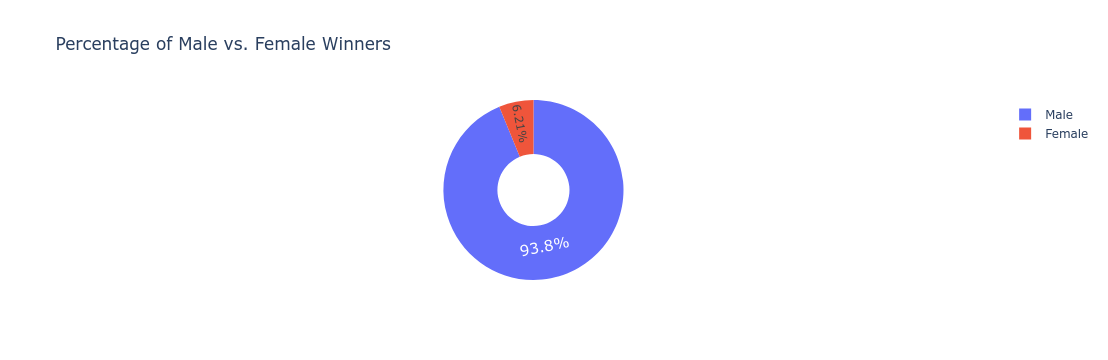

In [13]:
biology = df_data.sex.value_counts()
fig = px.pie(labels=biology.index, 
             values=biology.values,
             title="Percentage of Male vs. Female Winners",
             names=biology.index,
             hole=0.4,)

fig.update_traces(textposition='inside', textfont_size=15, textinfo='percent')

fig.show()

## 🏅 Find the Repeat Winners

In [14]:
is_winner = df_data.duplicated(subset=['full_name'], keep=False)
multiple_winners = df_data[is_winner]
print(f'There are {multiple_winners.full_name.nunique()}' \
      ' winners who weere awarded the prize more than once.')

There are 6 winners who weere awarded the prize more than once.


In [15]:
# --- Analysis Step ---
col_subset = ['year', 'category', 'laureate_type', 'full_name']
multiple_winners[col_subset]

,year,category,laureate_type,full_name
18,1903,Physics,Individual,"Marie Curie, née Sklodowska"
62,1911,Chemistry,Individual,"Marie Curie, née Sklodowska"
89,1917,Peace,Organization,Comité international de la Croix Rouge (Intern...
215,1944,Peace,Organization,Comité international de la Croix Rouge (Intern...
278,1954,Chemistry,Individual,Linus Carl Pauling
283,1954,Peace,Organization,Office of the United Nations High Commissioner...
297,1956,Physics,Individual,John Bardeen
306,1958,Chemistry,Individual,Frederick Sanger
340,1962,Peace,Individual,Linus Carl Pauling
348,1963,Peace,Organization,Comité international de la Croix Rouge (Intern...


## 📊 Number of Prizes per Category


In [16]:
# Number of different categories
df_data.category.nunique()

6

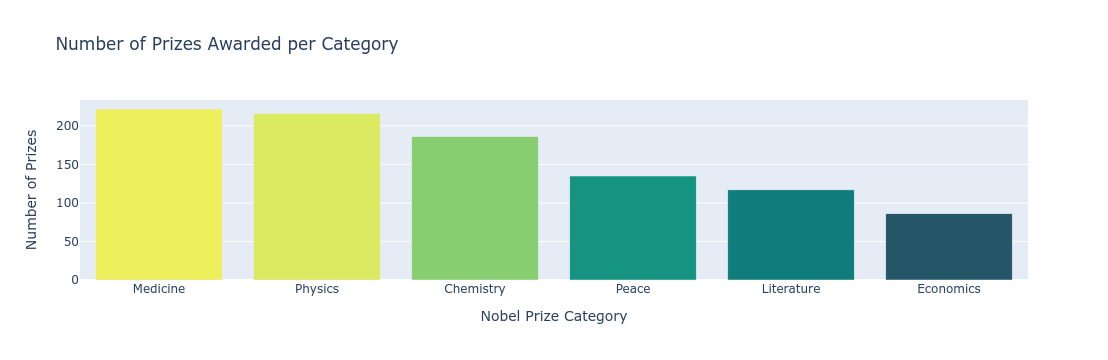

In [17]:
prizes_per_category = df_data.category.value_counts()
v_bar = px.bar(
        x = prizes_per_category.index,
        y = prizes_per_category.values,
        color = prizes_per_category.values,
        color_continuous_scale='Aggrnyl',
        title='Number of Prizes Awarded per Category')

v_bar.update_layout(xaxis_title='Nobel Prize Category', 
                    coloraxis_showscale=False,
                    yaxis_title='Number of Prizes')
v_bar.show()

## 🤼 Male and Female Winners by Category

In [18]:
cat_men_women = df_data.groupby(['category', 'sex'], 
                               as_index=False).agg({'prize': pd.Series.count})
cat_men_women.sort_values('prize', ascending=False, inplace=True)
cat_men_women

,category,sex,prize
11,Physics,Male,212
7,Medicine,Male,210
1,Chemistry,Male,179
5,Literature,Male,101
9,Peace,Male,90
3,Economics,Male,84
8,Peace,Female,17
4,Literature,Female,16
6,Medicine,Female,12
0,Chemistry,Female,7


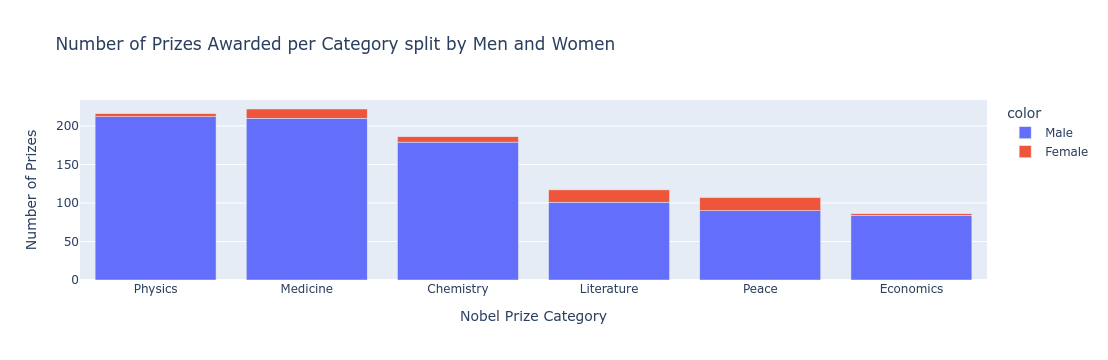

In [19]:
v_bar_split = px.bar(x = cat_men_women.category,
                     y = cat_men_women.prize,
                     color = cat_men_women.sex,
                     title='Number of Prizes Awarded per Category split by Men and Women')

v_bar_split.update_layout(xaxis_title='Nobel Prize Category', 
                          yaxis_title='Number of Prizes')
v_bar_split.show()

## 📈 Number of Prizes Awarded Over Time

In [20]:
prize_per_year = df_data.groupby(by='year').count().prize
moving_average = prize_per_year.rolling(window=5).mean()

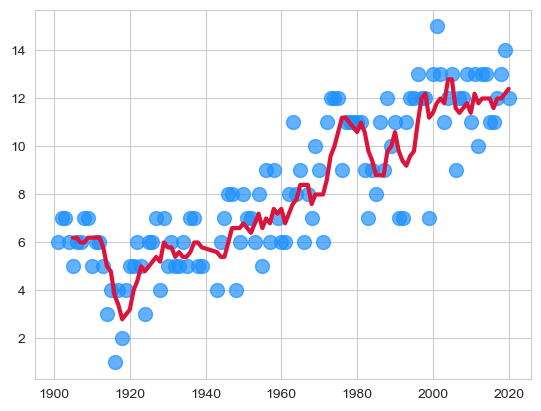

In [21]:
plt.scatter(x=prize_per_year.index, 
           y=prize_per_year.values, 
           c='dodgerblue',
           alpha=0.7,
           s=100,)

plt.plot(prize_per_year.index, 
        moving_average.values, 
        c='crimson', 
        linewidth=3,)

plt.show()

## Are More Prizes Shared Than Before?

In [22]:
yearly_avg_share = df_data.groupby(by='year').agg({'share_pct': pd.Series.mean})
share_moving_average = yearly_avg_share.rolling(window=5).mean()

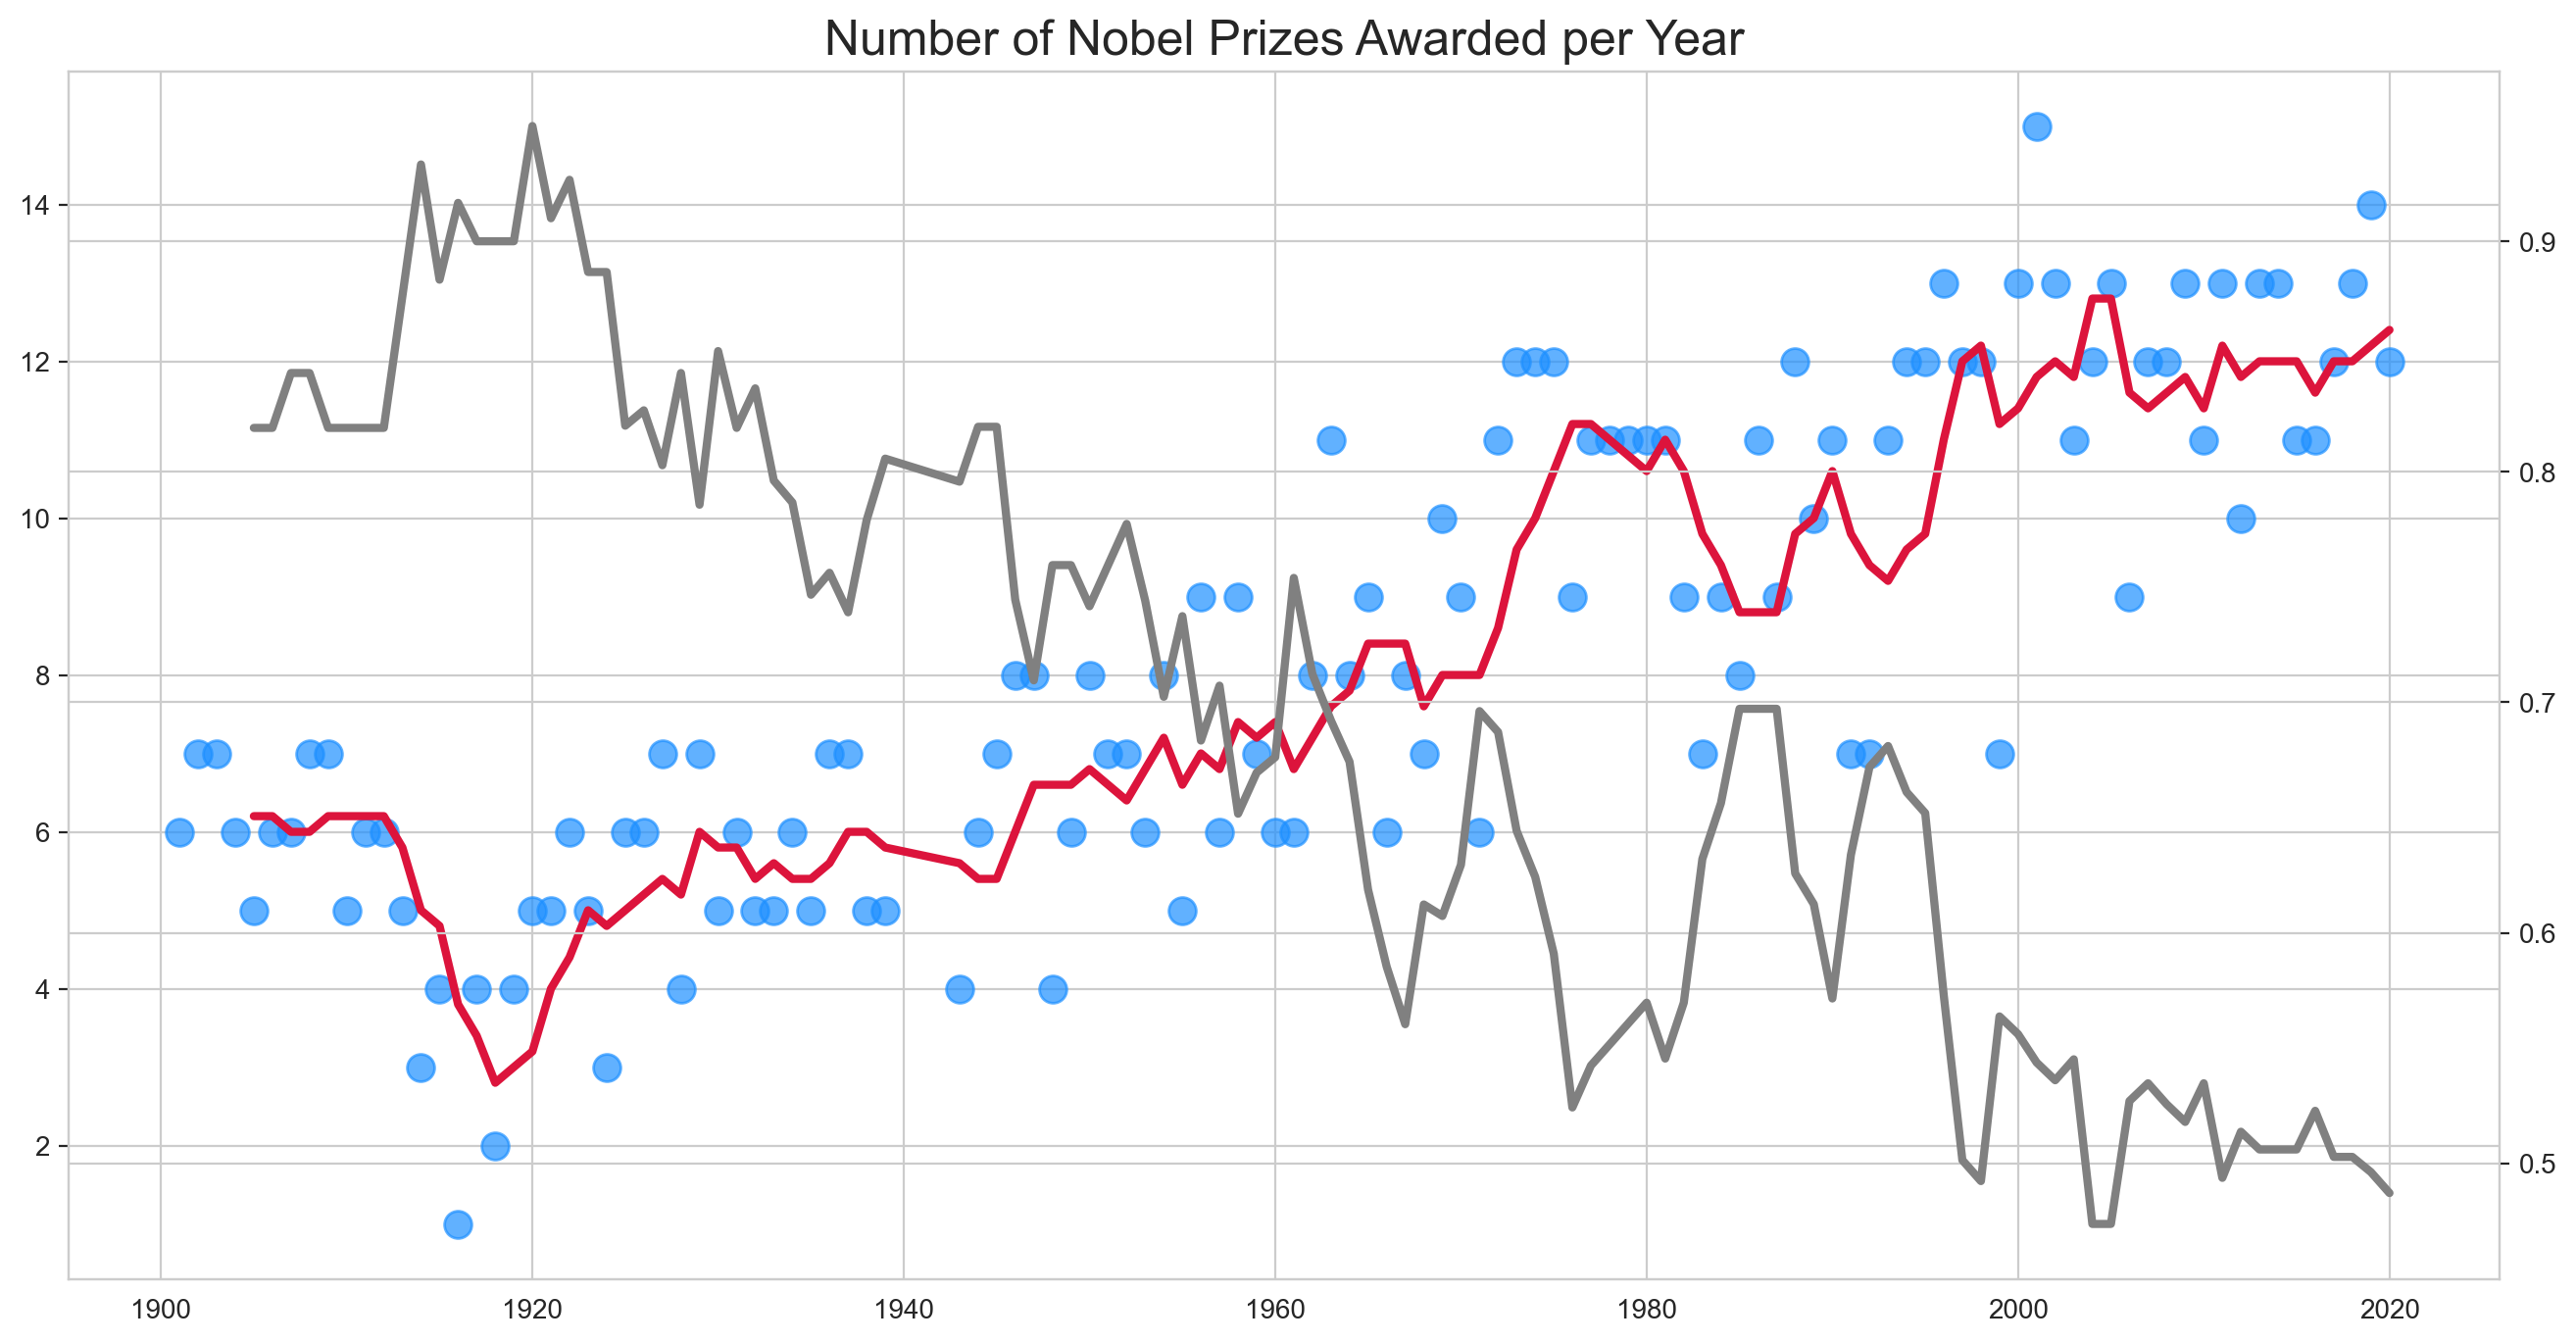

In [23]:
# --- Analysis Step ---
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)

ax1 = plt.gca()
ax2 = ax1.twinx() # create second y-axis

ax1.scatter(x=prize_per_year.index, 
           y=prize_per_year.values, 
           c='dodgerblue',
           alpha=0.7,
           s=100,)

ax1.plot(prize_per_year.index, 
        moving_average.values, 
        c='crimson', 
        linewidth=3,)

# Adding prize share plot on second axis
ax2.plot(prize_per_year.index, 
        share_moving_average.values, 
        c='grey', 
        linewidth=3,)

plt.show()

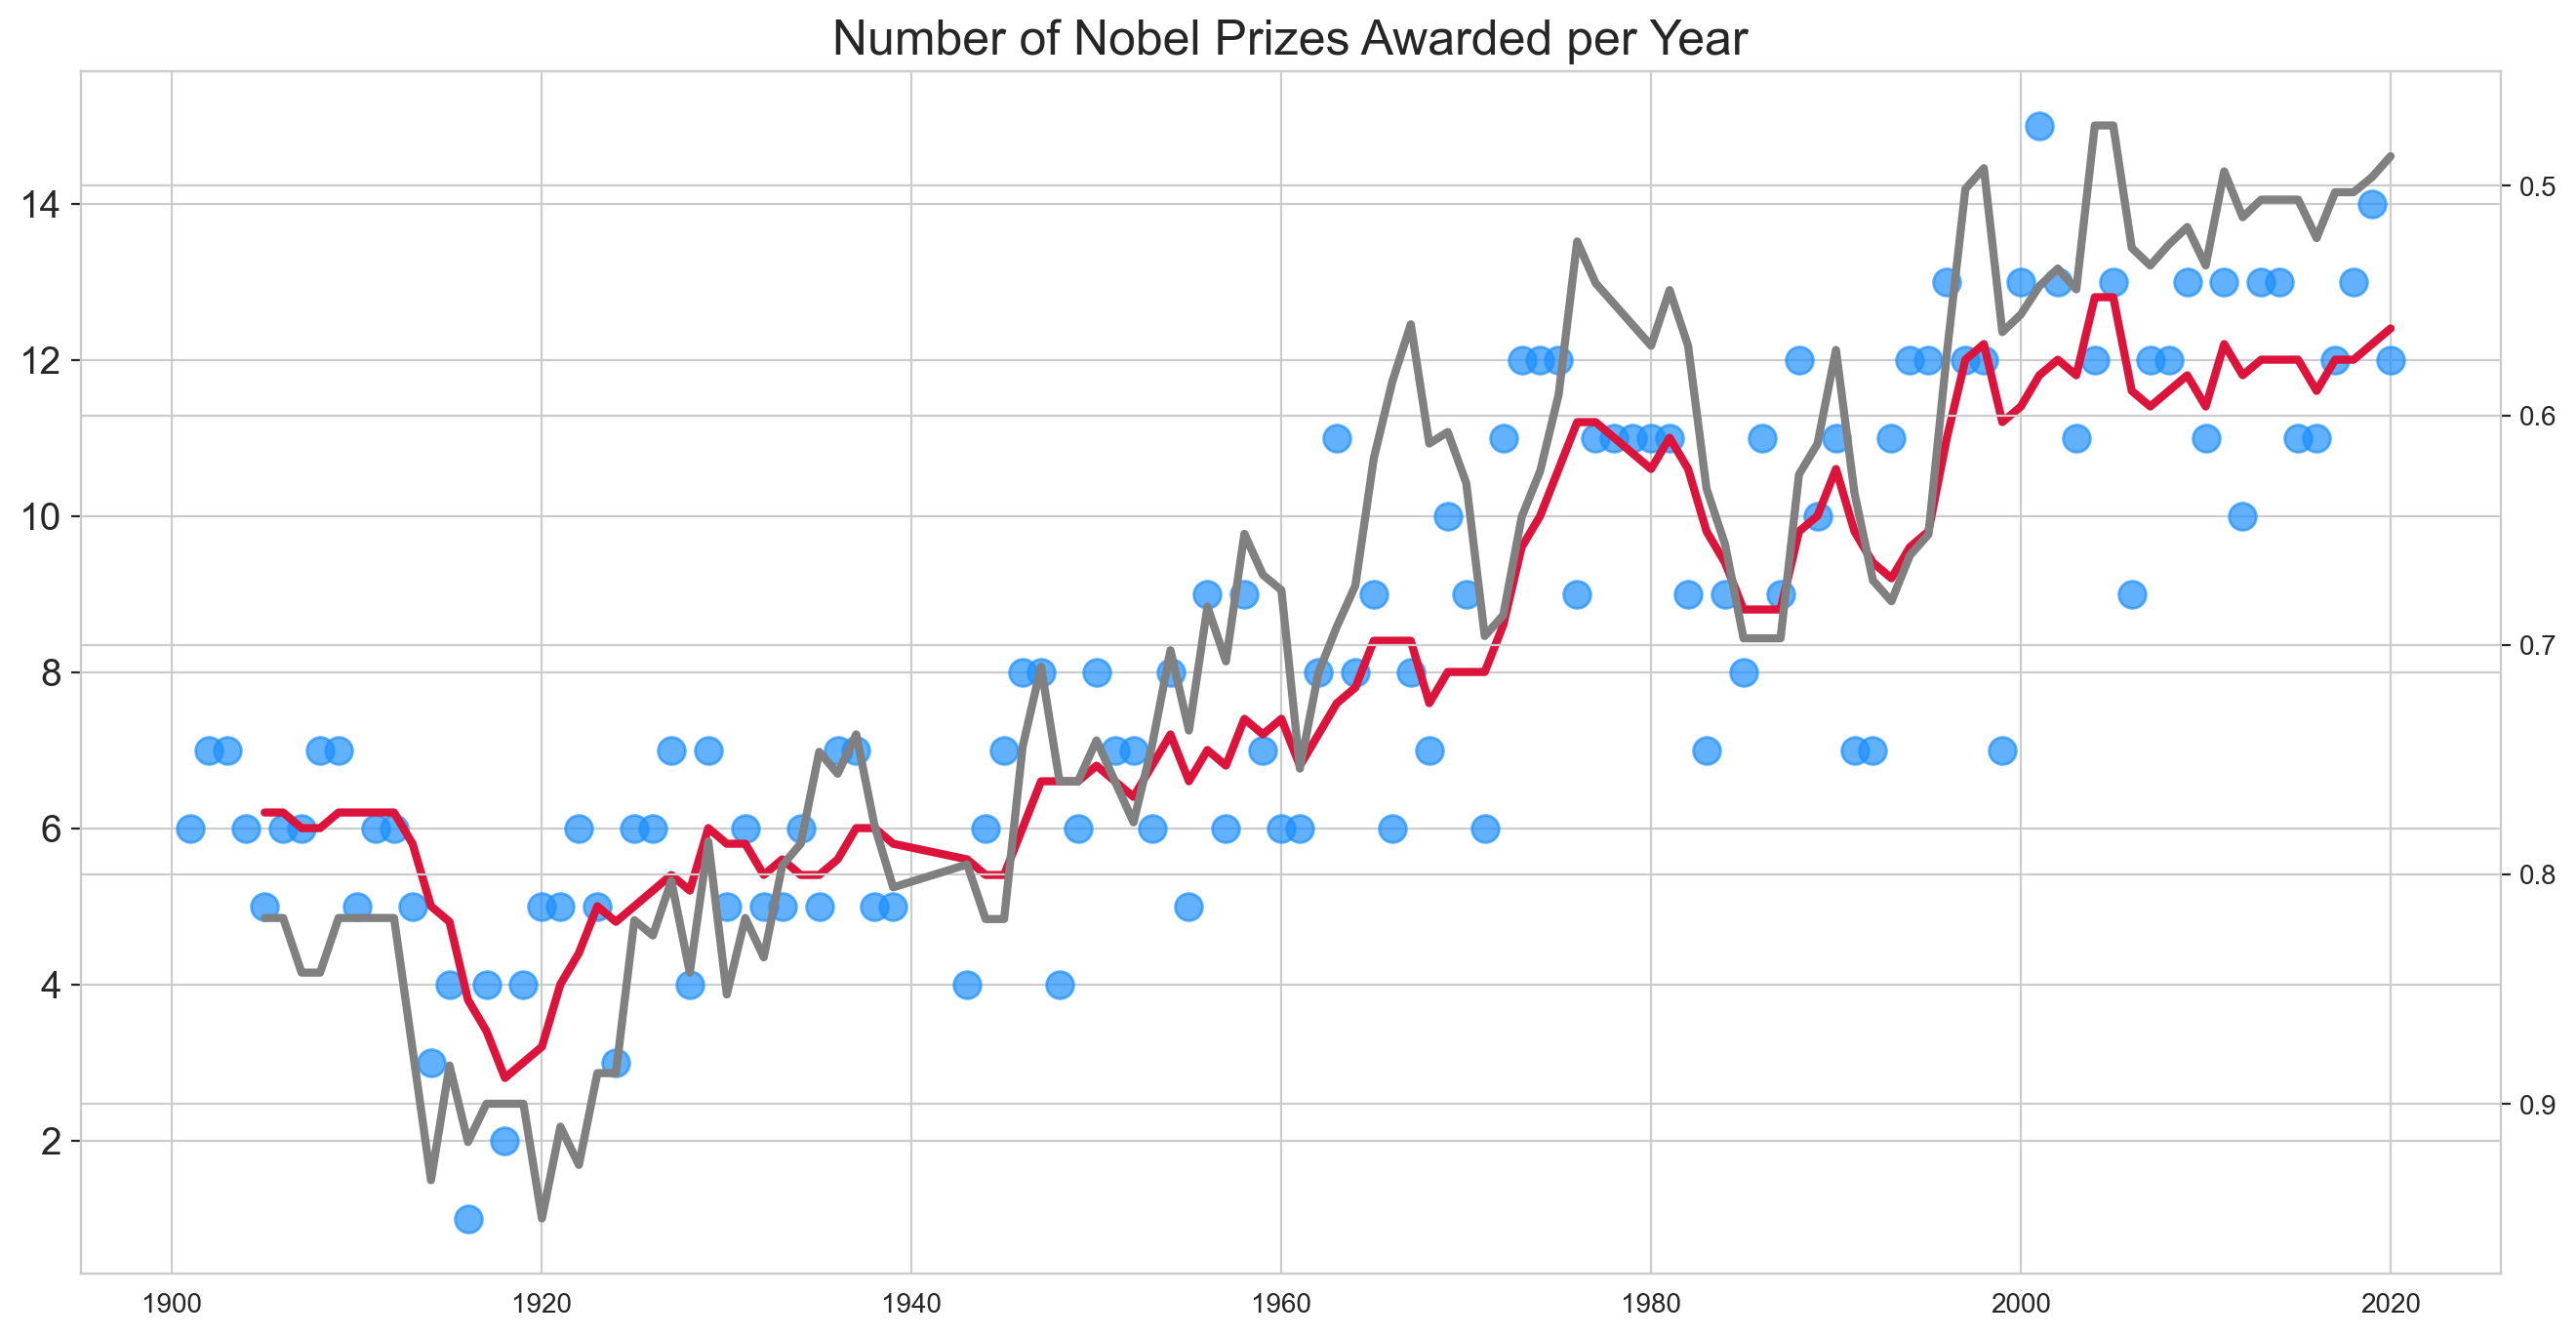

In [24]:
# --- Analysis Step ---
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)


ax1 = plt.gca()
ax2 = ax1.twinx()

# Can invert axis
ax2.invert_yaxis()

ax1.scatter(x=prize_per_year.index, 
           y=prize_per_year.values, 
           c='dodgerblue',
           alpha=0.7,
           s=100,)

ax1.plot(prize_per_year.index, 
        moving_average.values, 
        c='crimson', 
        linewidth=3,)

ax2.plot(prize_per_year.index, 
        share_moving_average.values, 
        c='grey', 
        linewidth=3,)

plt.show()

## 🌎 The Countries with the Most Nobel Prizes

In [25]:
top_countries = df_data.groupby(['birth_country_current'], 
                                  as_index=False).agg({'prize': pd.Series.count})

top_countries.sort_values(by='prize', inplace=True)
top20_countries = top_countries[-20:]
top20_countries

,birth_country_current,prize
33,India,9
31,Hungary,9
65,South Africa,9
2,Australia,10
20,Denmark,12
13,China,12
54,Norway,12
3,Austria,18
51,Netherlands,18
39,Italy,19


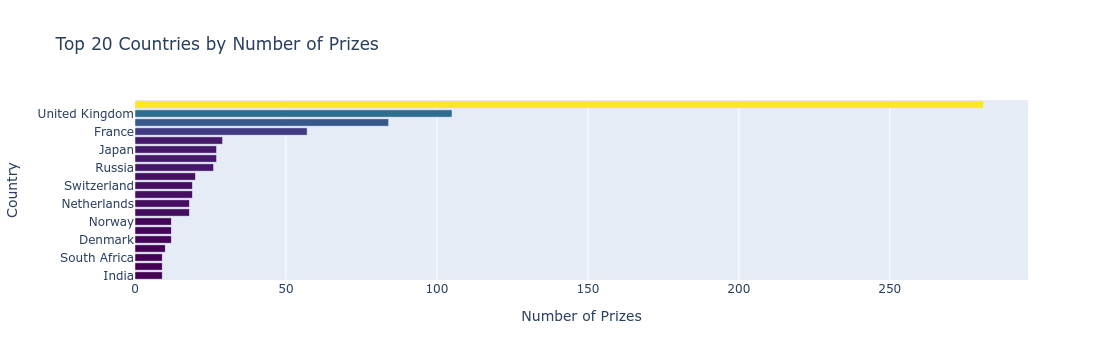

In [26]:
h_bar = px.bar(x=top20_countries.prize,
               y=top20_countries.birth_country_current,
               orientation='h',
               color=top20_countries.prize,
               color_continuous_scale='Viridis',
               title='Top 20 Countries by Number of Prizes')

h_bar.update_layout(xaxis_title='Number of Prizes', 
                    yaxis_title='Country',
                    coloraxis_showscale=False)
h_bar.show()

### 🌍 Nobel Laureates by Country (Choropleth Map)

In [27]:
# --- Analysis Step ---
df_countries = df_data.groupby(['birth_country_current', 'ISO'], 
                               as_index=False).agg({'prize': pd.Series.count})
df_countries.sort_values('prize', ascending=False)

,birth_country_current,ISO,prize
74,United States of America,USA,281
73,United Kingdom,GBR,105
26,Germany,DEU,84
25,France,FRA,57
67,Sweden,SWE,29
...,...,...,...
63,Slovakia,SVK,1
75,Venezuela,VEN,1
76,Vietnam,VNM,1
77,Yemen,YEM,1


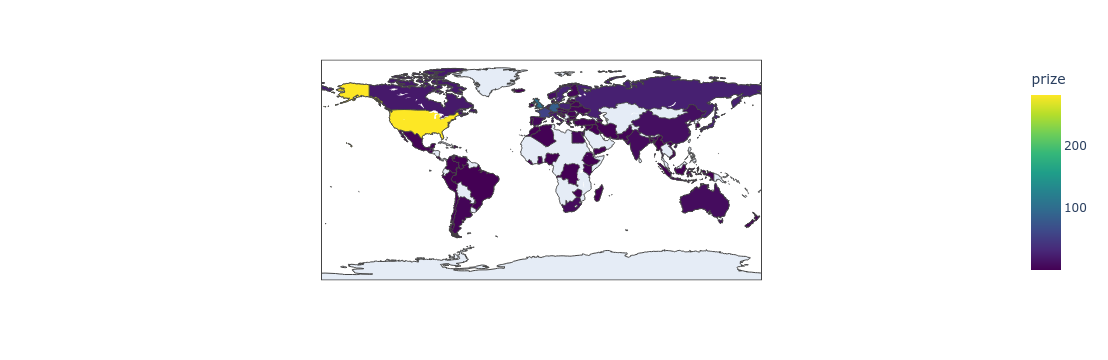

In [28]:
world_map = px.choropleth(df_countries,
                          locations='ISO',
                          color='prize', 
                          hover_name='birth_country_current', 
                          color_continuous_scale='Viridis')

world_map.update_layout(coloraxis_showscale=True,)

world_map.show()

## 🔎 📊 🏆 Number of Prizes Won by Each Country Over Time

In [29]:
prize_by_year = df_data.groupby(by=['birth_country_current', 'year'], as_index=False).count()
prize_by_year = prize_by_year.sort_values('year')[['year', 'birth_country_current', 'prize']]
prize_by_year

,year,birth_country_current,prize
312,1901,Netherlands,1
346,1901,Poland,1
118,1901,France,2
159,1901,Germany,1
440,1901,Switzerland,1
...,...,...,...
244,2019,India,1
221,2020,Germany,1
158,2020,France,1
533,2020,United Kingdom,2


In [30]:
cumulative_prizes = prize_by_year.groupby(by=['birth_country_current',
                                              'year']).sum().groupby(level=[0]).cumsum()
cumulative_prizes.reset_index(inplace=True)

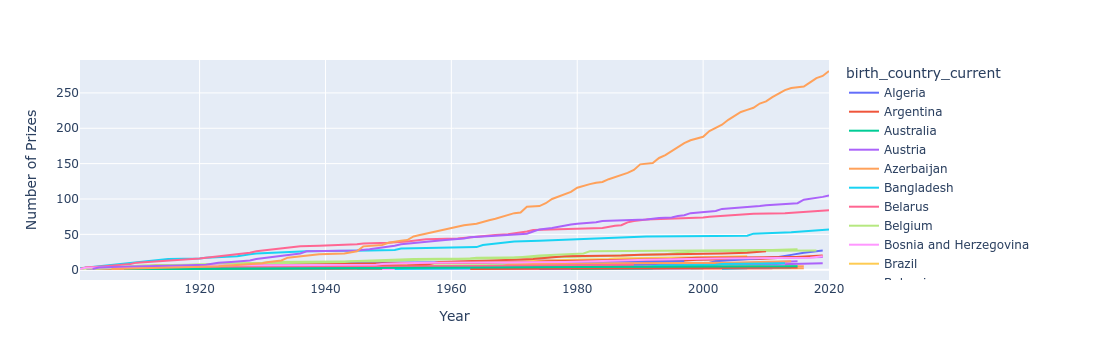

In [31]:
l_chart = px.line(cumulative_prizes,
                  x='year', 
                  y='prize',
                  color='birth_country_current',
                  hover_name='birth_country_current')

l_chart.update_layout(xaxis_title='Year',
                      yaxis_title='Number of Prizes')

l_chart.show()

## 🌞 Sunburst Chart – Category & Gender

In [32]:
# --- Analysis Step ---
country_city_org = df_data.groupby(by=['organization_country', 
                                       'organization_city', 
                                       'organization_name'], as_index=False).agg({'prize': pd.Series.count})

country_city_org = country_city_org.sort_values('prize', ascending=False)
country_city_org

,organization_country,organization_city,organization_name,prize
205,United States of America,"Cambridge, MA",Harvard University,29
280,United States of America,"Stanford, CA",Stanford University,23
206,United States of America,"Cambridge, MA",Massachusetts Institute of Technology (MIT),21
209,United States of America,"Chicago, IL",University of Chicago,20
195,United States of America,"Berkeley, CA",University of California,19
...,...,...,...,...
8,Austria,Innsbruck,Innsbruck University,1
6,Austria,Altenberg; Grünau im Almtal,Konrad-Lorenz-Institut der Österreichischen Ak...,1
5,Australia,Weston Creek,Australian National University,1
4,Australia,Nedlands,"NHMRC Helicobacter pylori Research Laboratory,...",1


In [33]:
burst = px.sunburst(country_city_org, 
                    path=['organization_country', 'organization_city', 'organization_name'], 
                    values='prize',
                    title='Where do Discoveries Take Place?',
                   )

burst.update_layout(xaxis_title='Number of Prizes', 
                    yaxis_title='City',
                    coloraxis_showscale=False)

burst.show()

## 🔬 Patterns in the Laureate Age at the Time of the Award

How Old Are the Laureates When the Win the Prize?

In [34]:
# Use Datetime object
birth_years = df_data['birth_date'].dt.year
df_data['winning_age'] = df_data.year - birth_years
df_data.winning_age

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    str           
 2   prize                  962 non-null    str           
 3   motivation             874 non-null    str           
 4   prize_share            962 non-null    str           
 5   laureate_type          962 non-null    str           
 6   full_name              962 non-null    str           
 7   birth_date             934 non-null    datetime64[us]
 8   birth_city             931 non-null    str           
 9   birth_country          934 non-null    str           
 10  birth_country_current  934 non-null    str           
 11  sex                    934 non-null    str           
 12  organization_name      707 non-null    str           
 13  organization_cit

In [36]:
display(df_data.nlargest(n=1, columns='winning_age'))
display(df_data.nsmallest(n=1, columns='winning_age'))

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning_age
937,2019,Chemistry,The Nobel Prize in Chemistry 2019,“for the development of lithium-ion batteries”,1/3,Individual,John Goodenough,1922-07-25,Jena,Germany,Germany,Male,University of Texas,Austin TX,United States of America,DEU,0.33,97.00


,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning_age
885,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,Individual,Malala Yousafzai,1997-07-12,Mingora,Pakistan,Pakistan,Female,NaN,NaN,NaN,PAK,0.50,17.00


## 🔎 📊 🏆 Descriptive Statistics for the Laureate Age at Time of Award

In [37]:
# --- Analysis Step ---
df_data.winning_age.describe()

count   934.00
mean     59.95
std      12.62
min      17.00
25%      51.00
50%      60.00
75%      69.00
max      97.00
Name: winning_age, dtype: float64

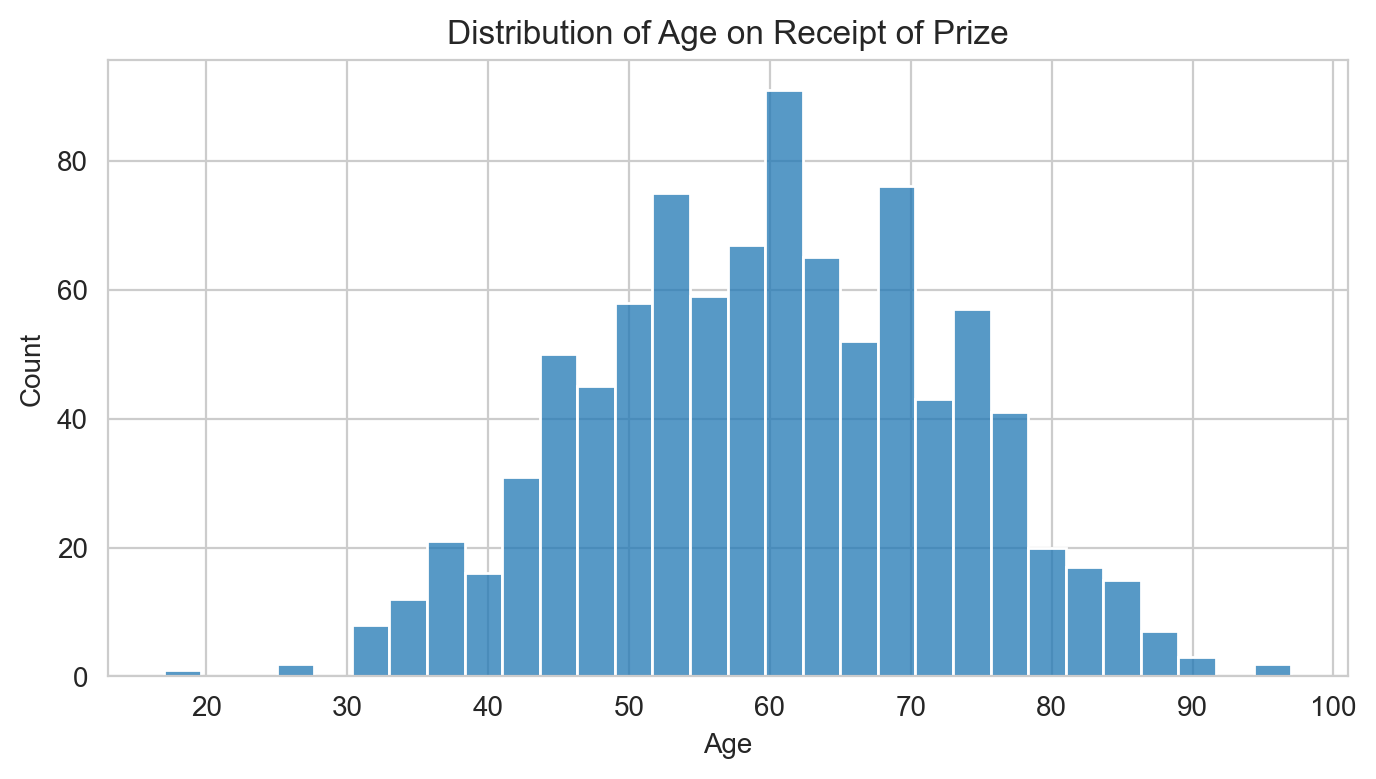

In [38]:
# --- Analysis Step ---
plt.figure(figsize=(8, 4), dpi=200)
sns.histplot(data=df_data,
             x=df_data.winning_age,
             bins=30)
plt.xlabel('Age')
plt.title('Distribution of Age on Receipt of Prize')
plt.show()

## 🔎 Winning Age Across the Nobel Prize Categories

How does the age of laureates vary by category? 

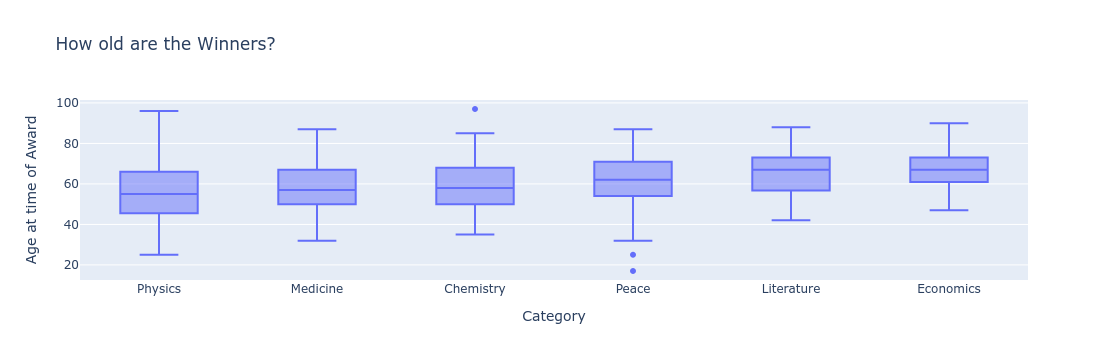

In [41]:
# Box plot using plotly
box = px.box(df_data, 
             x='category', 
             y='winning_age',
             title='How old are the Winners?')

box.update_layout(xaxis_title='Category',
                  yaxis_title='Age at time of Award',
                  xaxis={'categoryorder':'mean ascending'},)

box.show()